In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df=pd.read_csv('clean_loan_dataset.csv')

In [22]:
df.head()

,Unnamed: 0,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,0,2,Graduate,No,9600000,29900000,12,778,2400000.0,17050000.0,33700000.0,8000000.0,Approved
1,1,0,Not Graduate,Yes,4100000,12200000,8,417,11500000.0,2200000.0,8800000.0,3300000.0,Rejected
2,2,3,Graduate,No,9100000,29700000,20,506,7100000.0,7600000.0,33300000.0,12800000.0,Rejected
3,3,3,Not Graduate,No,8200000,30700000,8,467,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000.0,8200000.0,29400000.0,5000000.0,Rejected


In [23]:
df.isnull().sum()

Unnamed: 0                  0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [24]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [25]:
categorical=[]
numerical=[]

for col in df:
    if df[col].dtype=='O':
        categorical.append(col)
        
    else:
        numerical.append(col)

print("categorical cols:",categorical)
print()
print("numerical cols:",numerical)

categorical cols: ['education', 'self_employed', 'loan_status']

numerical cols: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


# <center>=====Visualising The Data====<center>

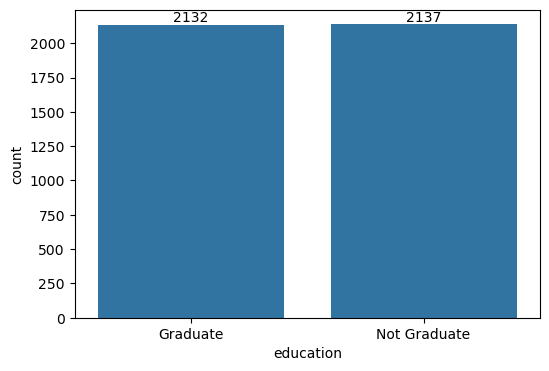

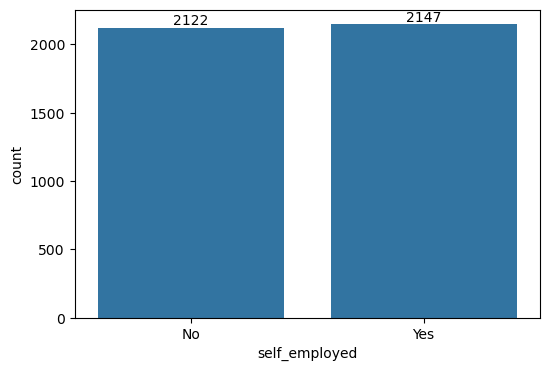

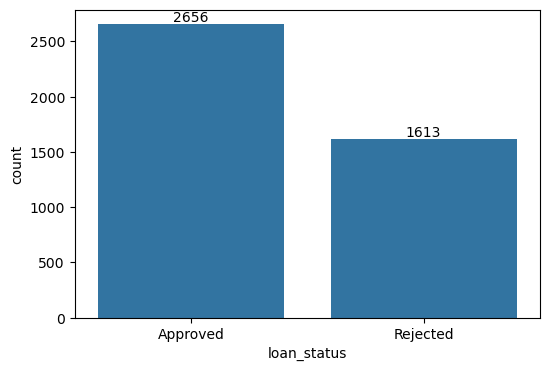

In [26]:
# countplot

for col in df[categorical]:
    plt.figure(figsize=(6,4))
    ax=sns.countplot(df[categorical],x=col)
    for bar in ax.containers:
        ax.bar_label(bar)

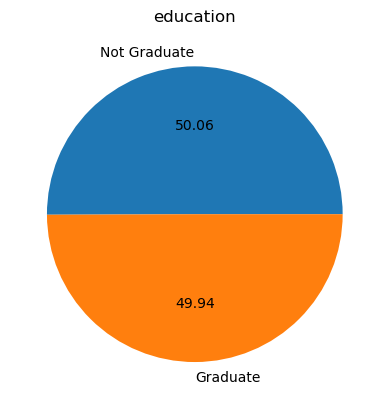

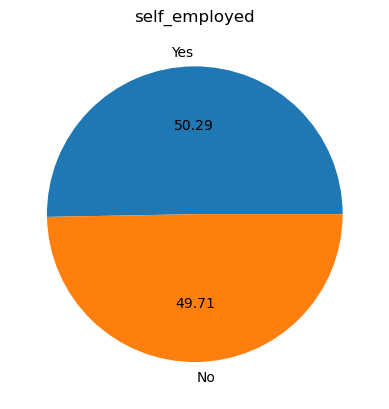

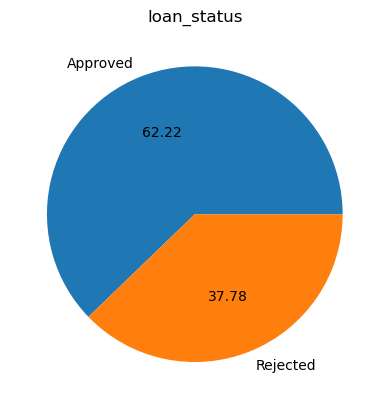

In [27]:
# pie chart of cols

for col in df[categorical]:
    df[col].value_counts()
    
    value=df[col].value_counts()
    index=df[col].value_counts().index
    
    plt.pie(x=value,labels=index,autopct='%.2f')
    plt.title(col)
    plt.show() 
    

> From the above graphs we see that in education column percentage of <b>Not Graduate(50.12%)</b> and <b>Graduate(49.88%)</b>
  is almost same . 
  
> And same for self employed column where percentage of <b>self employed(50.33%) and Not self employed(49.67%)</b> 
  is also almost equal.
  
> In Loan status column percentage of <b>Approved(62.22%) and rejected(37.78%).</b>

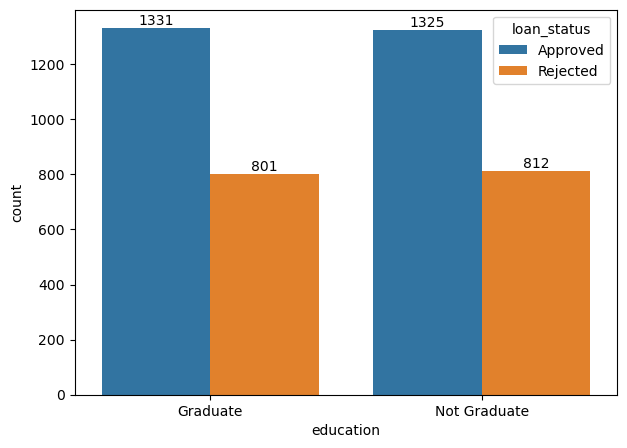

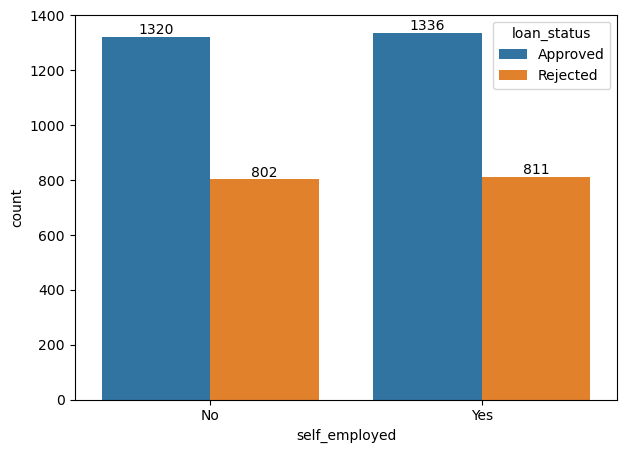

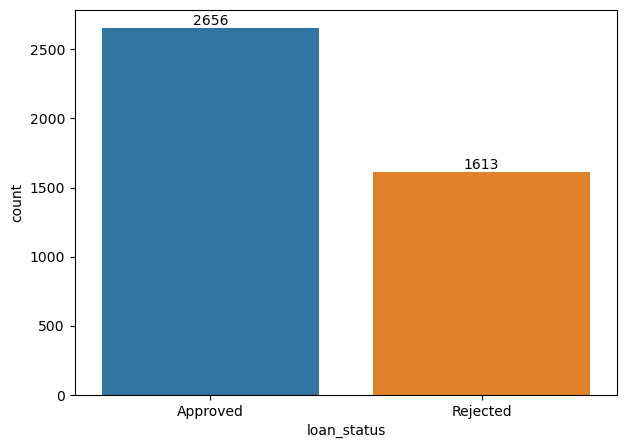

In [28]:
for col in df[categorical]:
    plt.figure(figsize=(7,5))
    ax=sns.countplot(df[categorical],x=col,hue='loan_status')
    for bar in ax.containers:
        ax.bar_label(bar)

> From the above graphs we can analysis that education does not affect the loan status as <b>Graduate and Not Graduate</b>
  people have almost same level of loan approved and reject.

> And same for self employment as <b>self employed people and Not self employed people</b> have almost same level of loan 
  approved and reject.

# <center>====Analysing Relation between columns====</center>

In [29]:
df[numerical].corr()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
no_of_dependents,1.000000,0.007266,-0.003366,-0.020111,-0.009998,0.004017,-0.001299,0.006680,0.014859
income_annum,0.007266,1.000000,0.927470,0.011488,-0.023034,0.598005,0.624797,0.878852,0.774053
loan_amount,-0.003366,0.927470,1.000000,0.008437,-0.017035,0.559320,0.588751,0.815974,0.720808
loan_term,-0.020111,0.011488,0.008437,1.000000,0.007810,0.001247,-0.007703,0.018007,0.011618
cibil_score,-0.009998,-0.023034,-0.017035,0.007810,1.000000,-0.013734,-0.004832,-0.024483,-0.017302
residential_assets_value,0.004017,0.598005,0.559320,0.001247,-0.013734,1.000000,0.379607,0.532774,0.442194
commercial_assets_value,-0.001299,0.624797,0.588751,-0.007703,-0.004832,0.379607,1.000000,0.552138,0.479642
luxury_assets_value,0.006680,0.878852,0.815974,0.018007,-0.024483,0.532774,0.552138,1.000000,0.677029
bank_asset_value,0.014859,0.774053,0.720808,0.011618,-0.017302,0.442194,0.479642,0.677029,1.000000


<Axes: >

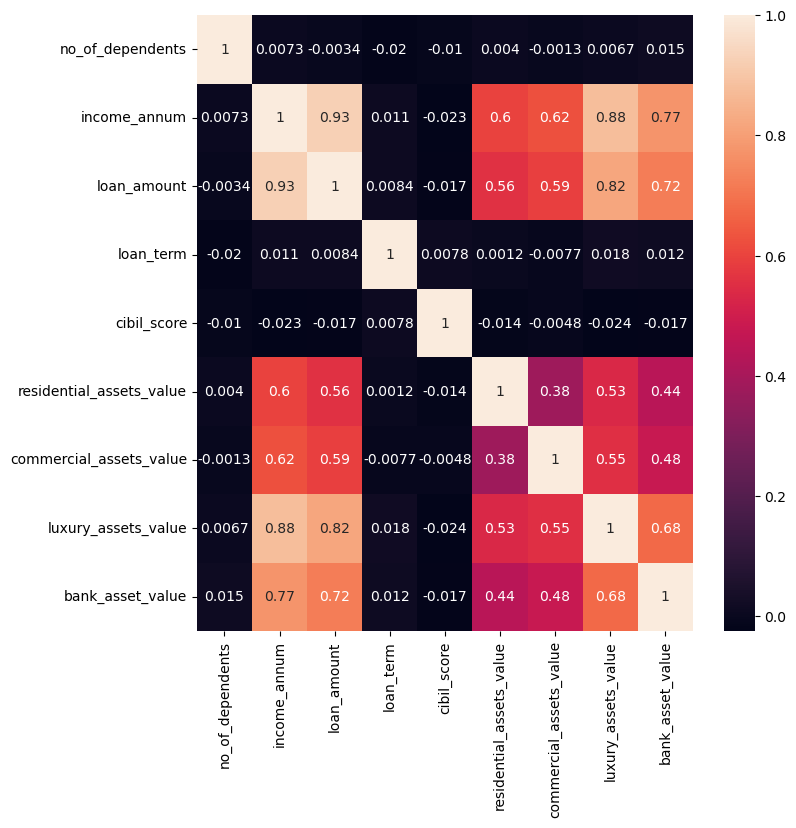

In [30]:
plt.figure(figsize=(8,8))
sns.heatmap(df[numerical].corr(),annot=True)

In [31]:
numerical

['no_of_dependents',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value']

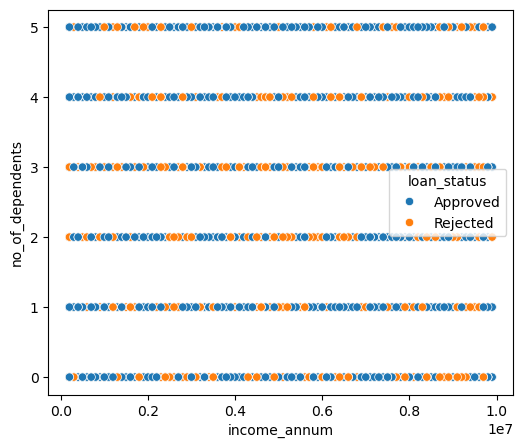

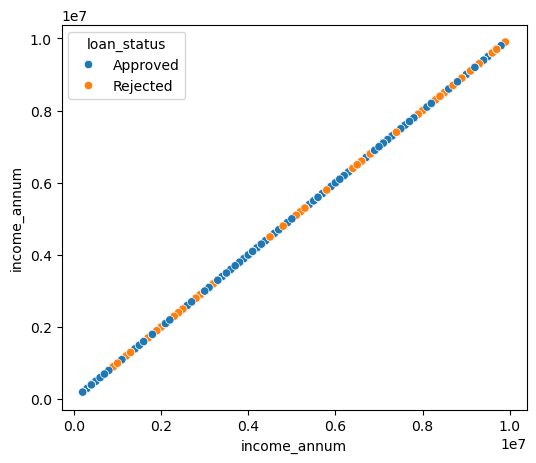

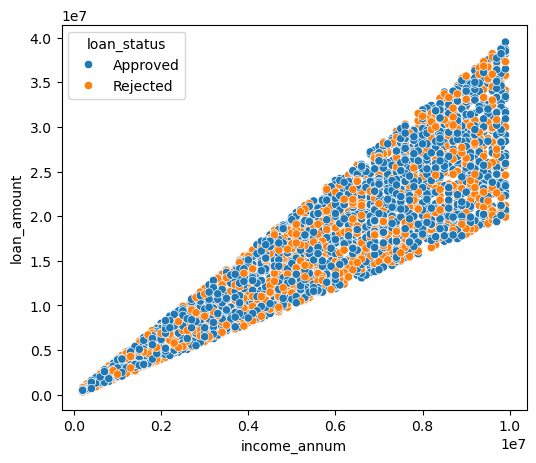

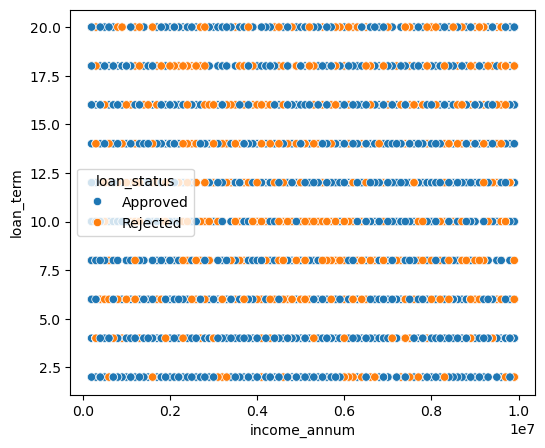

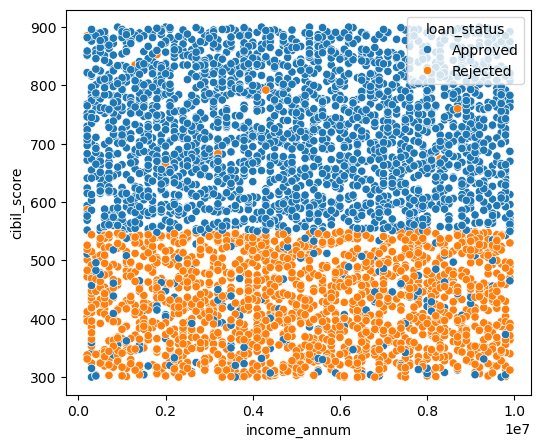

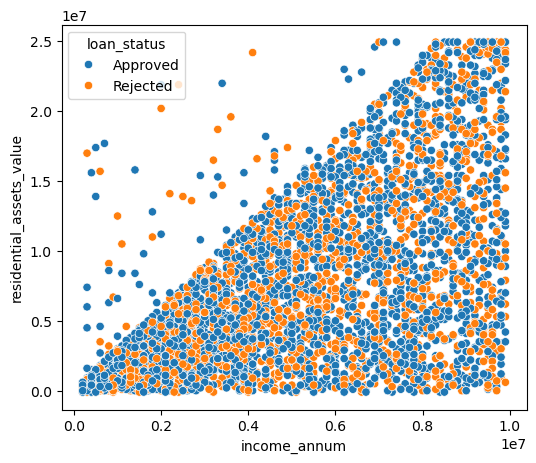

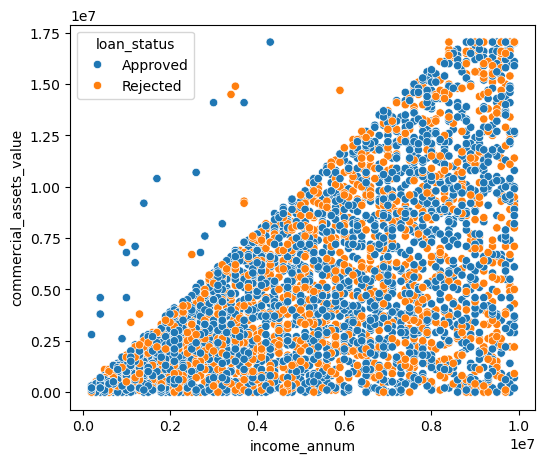

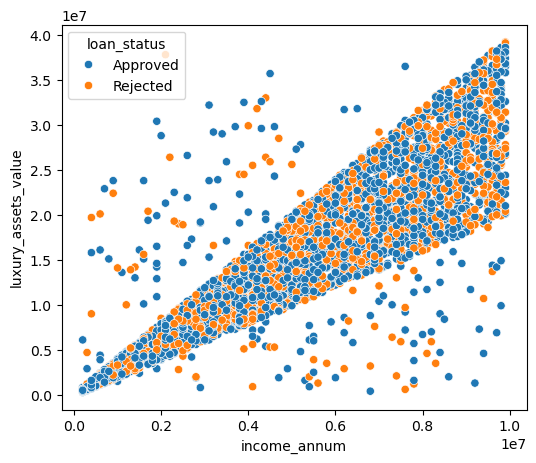

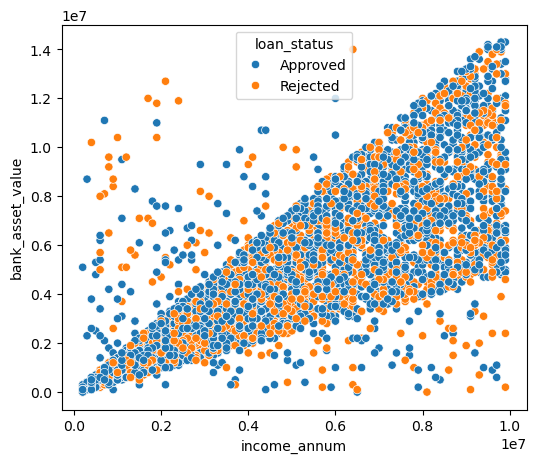

In [32]:
for num in df[numerical]:
    plt.figure(figsize=(6,5))
    sns.scatterplot(df,x='income_annum',y=num,hue='loan_status')    

> From the above graphs we can say that as income level increases than <b> bank_asset_value,luxury_assets_value ,
  commercial_assets_value,residential_assets_value and loan_amount</b> also increases/b>
  
> In <b>Cibil_score</b> it is very clear that people having score above than <b>550 have approved loan and below 
  than 550</b> are rejected. 